In [1]:
import os

os.chdir(r"C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire")

print(os.getcwd())

C:\Users\cerda\OneDrive\Bureau\Année 5\Methodes numeriques lineaire


Donne le champs de potentiel de vitesse
Chaque pixel de l'écran a une composante rouge, bleu et verte. Quand on charge une imagine, la matrice récoltée a des dimmensions, un nb de lignes et de colonnes. Et puis il y a quatre valeurs stockées : (R,G,B,A) A:niveau de transparence. La première partie du code permet de lire une image et convertie en matrice numpy. Et puis ensuite, il regarde la première valeur de la matrice (R), et il dit si cette composante est inférieur à certain seuil c'est un mur, sinon c'est du domaine de calcul. (On peut modifier ça si on veut). 
Noir : (0,0,0,1) et blanc : (1,1,1,1). 

pas de notion de décentrer pour les vitesses 

A_top: 209276it [00:01, 126438.37it/s]
A_bottom: 209276it [00:01, 136034.97it/s]
A_left: 209276it [00:01, 135122.78it/s]
A_right: 209276it [00:01, 121915.65it/s]
A_center: 209276it [00:06, 33640.28it/s]


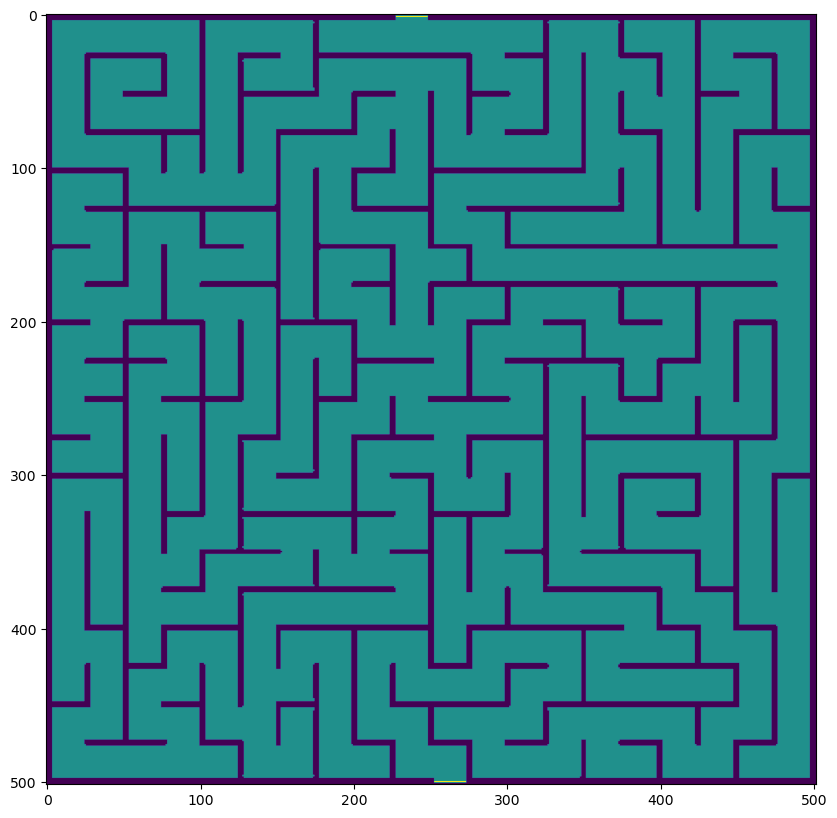

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.sparse import csc_array as csr
from scipy.sparse.linalg import spsolve, gmres, cg, splu
from tqdm import tqdm

def laplace_pot(domain, outside_value = 0, inside_value = 1, pot_in = 1., pot_out = -1.):
    """
    Calcul d'un écoulement irrotationnel en potentiel de vitesse sur base d'une matrice de domaine

    outside_value = valeur considérée hors domaine
    inside_value  = valeur considérée dans le domaine de calcul
    pot_in        = potentiel imposé en entrée
    pot_out       = potentiel imposé en sortie
    """
    # recherche de la zone permettant de circonscrir la zone hors domaine
    outside= np.where(domain==outside_value)
    i1 = outside[0].min()
    i2 = outside[0].max()
    j1 = outside[1].min()
    j2 = outside[1].max()

    # Restriction de la matrice à la zone utile
    domain=domain[i1:i2+1,j1:j2+1]

    # Recherche des coordonnées hors et dans le domaine
    outside= np.where(domain==outside_value)
    inside = np.where(domain==inside_value)

    # Nombre de points de calcul
    nb = len(inside[0])

    # Matrice de numérotation
    numb_vec  = np.arange(0, nb, dtype=np.int32)
    #   Utilisation d'un stockage CSR par facilité --> mais "lent" pour la recherche des voisins (environ 60x plus lent pour l'image d'exemple)
    # numbering = csr((numb_vec, (inside[0], inside[1])), shape=array.shape)
    #
    # Utilisation d'une matrice pleine --> plus "rapide" pour la recherche des voisins mais demande éventuellement plus de mémoire
    numbering = np.zeros(domain.shape, dtype=np.int32)
    numbering[inside] = numb_vec

    # Recherche des zones CL
    #  - amont : ligne supérieure
    #  - aval : ligne inférieure
    inlet  = np.where(domain[0,:]==inside_value)[0]
    outlet = np.where(domain[-1,:]==inside_value)[0]

    b  = np.zeros(nb)
    b[0:len(inlet)] = pot_in
    b[-len(outlet):]= pot_out

    # Remplissage de la matrice de poids en CSR
    # *****************************************
    # Création par "List comprehension"
    Aij_inlet  = [ [1., numbering[0 ,j], numbering[0  ,j  ]] for j in list(inlet)]
    Aij_outlet = [ [1., numbering[-1,j], numbering[-1 ,j  ]] for j in list(outlet)]

    Aij_top    = [ [1., numbering[i ,j], numbering[i-1,j  ]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_top')    if i!=0 and i!=domain.shape[0]-1 if domain[i-1,j  ] == inside_value]
    Aij_bottom = [ [1., numbering[i ,j], numbering[i+1,j  ]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_bottom') if i!=0 and i!=domain.shape[0]-1 if domain[i+1,j  ] == inside_value]
    Aij_left   = [ [1., numbering[i ,j], numbering[i  ,j-1]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_left')   if i!=0 and i!=domain.shape[0]-1 if domain[i  ,j-1] == inside_value]
    Aij_right  = [ [1., numbering[i ,j], numbering[i  ,j+1]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_right')  if i!=0 and i!=domain.shape[0]-1 if domain[i  ,j+1] == inside_value]

    def count_neigh(i,j):
        count = 0
        if domain[i-1,j] == inside_value:
            count+=1
        if domain[i+1,j] == inside_value:
            count+=1
        if domain[i,j-1] == inside_value:
            count+=1
        if domain[i,j+1] == inside_value:
            count+=1

        return float(count)

    Aij_center = [ [-count_neigh(i,j), numbering[i,j], numbering[i,j]] for i,j in tqdm(zip(inside[0], inside[1]), 'A_center') if i!=0 and i!=domain.shape[0]-1]

    A_parts = [Aij_inlet, Aij_outlet, Aij_left, Aij_right, Aij_bottom, Aij_top, Aij_center]
    A  = [cur[0] for cur_part in A_parts for cur in cur_part]
    ii = [cur[1] for cur_part in A_parts for cur in cur_part]
    jj = [cur[2] for cur_part in A_parts for cur in cur_part]

    # Création de la CSR sur base des vecteurs de valeurs et des indices de position
    csr_a = csr((A,(ii,jj)))

    # Résolution du système
    x = spsolve(csr_a,b)

    # Remplissage de la matrice de résultat sur base du vecteur x
    pot = np.zeros(domain.shape, dtype=np.float64)
    pot[inside] = x

    # Classification du domaine selon la convention
    #   - 0 = hors domaine
    #   - 1 = domaine intérieur
    #   - 2 = conditions limites
    domain[outside] = 0
    domain[inside]  = 1
    domain[0,inlet]   = 2
    domain[-1,outlet]  = 2

    #ajout d'un bord de 0 sur tout le pourtour
    new_dom = np.zeros((domain.shape[0]+2, domain.shape[1]+2), dtype=np.int32)
    new_dom[1:-1,1:-1] = np.int32(domain)
    new_pot = np.zeros((domain.shape[0]+2, domain.shape[1]+2), dtype=np.float64)
    new_pot[1:-1,1:-1] = pot


    return new_dom, new_pot

def compute(filepath:str, fileout:str = 'out'):
    # Import du module PIL pour lire n'importe quelle image
    from PIL import Image
    # Lecture d'une image
    im = Image.open(filepath)

    # Conversion de l'image en matrice Numpy
    array = np.asarray(im)[:,:,0].copy() # uniquement la composante R d'une image RGB --> à particulariser si l'image est pure N&B par exemple

    # La matrice contient des valeurs comprises entre 0 et 255

    # Filtrage du 'gris' --> image N&B
    #  seuil arbitraire à 200
    array[np.where(array<=200)]= 0
    array[np.where(array>200)] = 1

    # Calcul du laplacien du potentiel
    domain, pot = laplace_pot(array,
                            outside_value=0,
                            inside_value=1,
                            pot_in=100.,
                            pot_out=-100.)

    fig, ax = plt.subplots(1,1)
    fig.set_size_inches(10,10)
    ax.imshow(pot)
    fig.savefig(fileout+'.png')

    ax.imshow(domain)
    fig.savefig('domain.png')

    np.savetxt(fileout+'_domain.txt', domain, fmt='%i')
    np.savetxt(fileout+'_pot.txt', pot, fmt='%15.10f')
    np.save(fileout+'_pot.npy', pot)

if __name__ == "__main__":

    compute('laby.png', 'out')

Le code ci dessous permet de mettre en place les données nécessaires à la résolution de l'équation. 
Il commence par charger les données 
Définit les tableaux des vitesses horizontales et verticales (ne stock pas de vitesses tangentielles)
Calcule les vitesses sur les faces internes 

L'idée de ce bout de code, c'est de passer d'un potentiel phi, connu au centre des cellules, à des vitesses afin de résoudre un schéma volumes finis. 
On a un fichier contenant phi aux centre de chaque pixel et une carte du labyrinthe. 
L'équation en volume fini a besoin du flux de c à travers chaque face. 
On utilise le fait que la vitesse = gradient de phi
Vu qu'on suppose un écoulement irrotatinnel, la vitesse dérive d'un potentiel. On discrètise le gradient en une différence de phi entre deux cellules / distance. 
La face est située entre les deux centres, donc on a une différence centrée, càd un ordre 2. 

Les murs sont impérméables, donc sis l'une des deux cellules est un mur, la vitesse de la face est mise à zéro. 

Pour les faces d'entrée et de sortie, on utilise une règle de continuité, tout ce qui entre dans une cellule ressort de l'autre côté. 

Pour simplifier le calcul de delta t, on divise par la vitesse max. ça change rien parce que l'advection est linéaire en vitesse. 

Il faut ensuite vérifier que ce qu'on obtient est cohérent, c'est à dire la divergence = 0, les débits entrant = débits sortants, et l'écoulement va de l'entrée vers la sortie. 


Divergence max (cellules intérieures) : 7.337315379275551e-13
Débit entrant : 6.9974524061117584  Débit sortant : 6.997452403851093


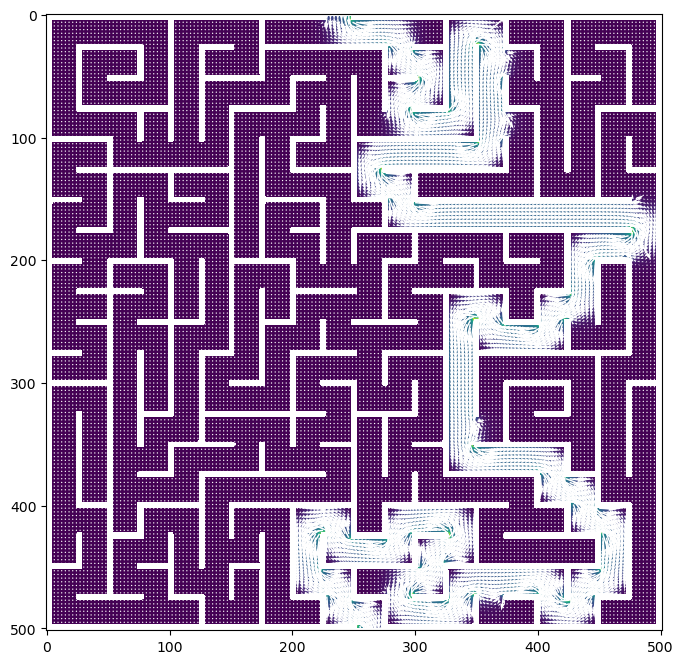

In [5]:
import numpy as np
import matplotlib.pyplot as plt

#Etape N°1 : Chargement des données 

phi = np.load('out_pot.npy') #Potentiel, taille (Ny,Nx)
dom = np.loadtxt('out_domain.txt', dtype=int) #carte du domaine, 0 = mur et 1 = celulle fluide intérieur , 2 = celulle d'entrée ou de sortie
Ny, Nx = phi.shape #taille de la matrice phi
dx = dy = 1.0 #Pixel de taille 1 
fluid = dom > 0  #masque booléen des cellules fluides. 
#Sert à savoir directement si une cellule est du fluide ou non (= VRAI si fluide intérieur ou fluide d'entrée ou de sortie et FALSE si mur)
#Il servira plus tard à imposer l'impérméabilité des parois 

#Etape N°2 : Définition des tableaux des vitesses

# U[i,j] : face gauche de la cellule (i,j) et U[i,j+1] est sa face droite
# V[i,j] : face haute  de la cellule (i,j) et V[i+1,j] est sa face basse
U = np.zeros((Ny, Nx + 1)) #tableau des vitesse horizontales de taille (Ny, Nx+1)
V = np.zeros((Ny + 1, Nx)) #tableau des vitesses verticales de taille (Ny+1, Nx)
#ces deux tableaux seront calculé à partir de la différence de phi entre deux cellules voisines

#Etape N°3 : Faces internes (calcul des vitesses sur les faces). 
#Pour une face entre deux cellules voisines, la vitesse est la pente de phi enter ces deux cellules. 
#face_U vaut True si les deux cellules de part et d'autre de la face sont fluides 

face_U = fluid[:, 1:] & fluid[:, :-1]
U[:, 1:Nx] = np.where(face_U, -(phi[:, 1:] - phi[:, :-1]) / dx, 0.0)

face_V = fluid[1:, :] & fluid[:-1, :]
V[1:Ny, :] = np.where(face_V, -(phi[1:, :] - phi[:-1, :]) / dy, 0.0)

# Les faces où l'une des deux cellules est un mur restent à 0 (imperméable)

#Etape n°4 : Traitement des faces d'entrée et de sortie 
#les faces d'entrée et de sortie ont un dom = 2 et donc un fluid = False

rows_bc = np.where((dom == 2).any(axis=1))[0] #repère les lignes contenant des 2, donc celles qui sont des murs
i_in, i_out = rows_bc.min(), rows_bc.max()
j_in  = np.where(dom[i_in, :]  == 2)[0]
j_out = np.where(dom[i_out, :] == 2)[0]

V[i_in, j_in]        = V[i_in + 1, j_in]     # face haute reçoit la valeur de la face basse
V[i_out + 1, j_out]  = V[i_out, j_out]       # face basse reçoit la valeur de la face haute

#Etape n°5 : On normalise les valeurs de U et V en divisant par la vitesse maximale
#ça sert à simplifier le pas de temps 
vmax = max(np.abs(U).max(), np.abs(V).max())
U /= vmax
V /= vmax

#Etape n°6 : Bilan des cellules 
#On fait un bilan de chaque cellule (face droit - face gauche + face basse - face haute)
#Donc ce qui rentre = ce qui sort car écoulement incompressible

div = (U[:, 1:] - U[:, :-1]) / dx + (V[1:, :] - V[:-1, :]) / dy
inner = dom == 1
print("Divergence max (cellules intérieures) :", np.abs(div[inner]).max())

Q_in  = V[i_in, j_in].sum() * dx
Q_out = V[i_out + 1, j_out].sum() * dx
print("Débit entrant :", Q_in, " Débit sortant :", Q_out)

#Etape N°7 : Visualisation des données 
#partie juste pour l'affichage, on fait la moyenne des deux faces de chaque cellule pour avoir juste un vecteur par cellule. 
#juste pour l'affichage car le solveur utilisera U et V au faces. 
uc = 0.5 * (U[:, :-1] + U[:, 1:])            # vitesse au centre des cellules
vc = 0.5 * (V[:-1, :] + V[1:, :])
speed = np.where(fluid, np.hypot(uc, vc), np.nan)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(speed)
s = 3                                          # on affiche une flèche sur s
Y, X = np.mgrid[0:Ny:s, 0:Nx:s]
ax.quiver(X, Y, uc[::s, ::s], vc[::s, ::s], angles='xy', color='w')
plt.show()

np.save('U.npy', U)
np.save('V.npy', V)

Réécrire le code à ma manière et pas juste prendre celui de Claude

Divergence max (cellules intérieures) : 7.337315379275551e-13
Débit entrant : 6.9974524061117584  Débit sortant : 6.997452403851093


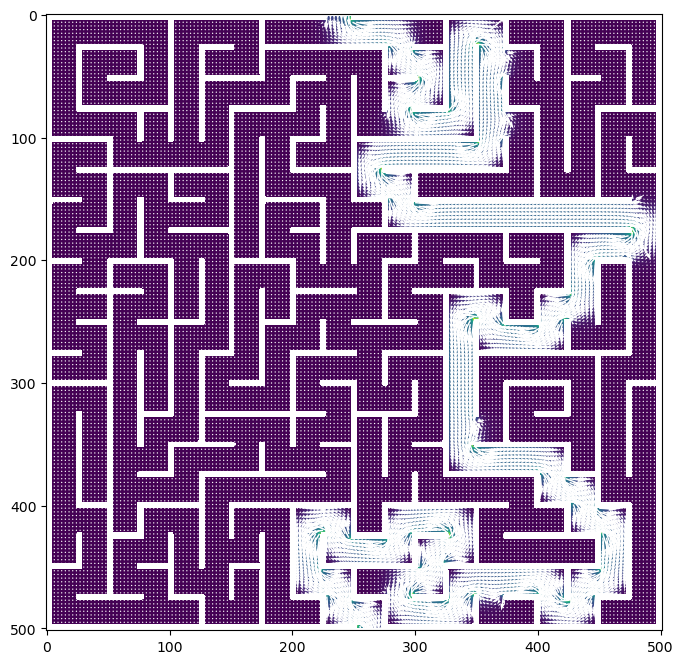

In [12]:
import numpy as np
import matplotlib.pyplot as plt

#Etape N°1 : Chargement des données 

phi = np.load('out_pot.npy') #Potentiel, taille (Ny,Nx)
dom = np.loadtxt('out_domain.txt', dtype=int) #carte du domaine, 0 = mur et 1 = celulle fluide intérieur , 2 = celulle d'entrée ou de sortie
Ny, Nx = phi.shape #taille de la matrice phi
dx = dy = 1.0 #Pixel de taille 1 
fluid = np.zeros((Ny, Nx), dtype=bool)
for i in range(Ny):
    for j in range(Nx):
        if dom[i, j] == 1 or dom[i, j] == 2:
            fluid[i, j] = True
#masque booléen des cellules fluides. 
#Sert à savoir directement si une cellule est du fluide ou non (= VRAI si fluide intérieur ou fluide d'entrée ou de sortie et FALSE si mur)
#Il servira plus tard à imposer l'impérméabilité des parois 

#Etape N°2 : Définition des tableaux des vitesses

# U[i,j] : face gauche de la cellule (i,j) et U[i,j+1] est sa face droite
# V[i,j] : face haute  de la cellule (i,j) et V[i+1,j] est sa face basse
U = np.zeros((Ny, Nx + 1)) #tableau des vitesse horizontales de taille (Ny, Nx+1) (il y a Nx cellules donc Nx+1 faces)
V = np.zeros((Ny + 1, Nx)) #tableau des vitesses verticales de taille (Ny+1, Nx) (il y a Ny cellules dont Ny+1 faces)
#ces deux tableaux seront calculé à partir de la différenec de phi entre deux cellules voisines dans la suite du calcul

#Etape N°3 : Faces internes (calcul des vitesses sur les faces). 
#Pour une face entre deux cellules voisines, la vitesse est la pente de phi enter ces deux cellules. 
#face_U vaut True si les deux cellules de part et d'autre de la face sont fluides 

face_U = fluid[:, 1:] & fluid[:, :-1]
U[:, 1:Nx] = np.where(face_U, -(phi[:, 1:] - phi[:, :-1]) / dx, 0.0)

face_V = fluid[1:, :] & fluid[:-1, :]
V[1:Ny, :] = np.where(face_V, -(phi[1:, :] - phi[:-1, :]) / dy, 0.0)

# Les faces où l'une des deux cellules est un mur restent à 0 (imperméable)

#Etape n°4 : Traitement des faces d'entrée et de sortie 
#les faces d'entrée et de sortie ont un dom = 2 et donc un fluid = False

rows_bc = np.where((dom == 2).any(axis=1))[0] #repère les lignes contenant des 2, donc celles qui sont des murs
i_in, i_out = rows_bc.min(), rows_bc.max()
j_in  = np.where(dom[i_in, :]  == 2)[0]
j_out = np.where(dom[i_out, :] == 2)[0]

V[i_in, j_in]        = V[i_in + 1, j_in]     # face haute reçoit la valeur de la face basse
V[i_out + 1, j_out]  = V[i_out, j_out]       # face basse reçoit la valeur de la face haute

#Etape n°5 : On normalise les valeurs de U et V en divisant par la vitesse maximale
#ça sert à simplifier le pas de temps 
vmax = max(np.abs(U).max(), np.abs(V).max())
U /= vmax
V /= vmax

#Etape n°6 : Bilan des cellules 
#On fait un bilan de chaque cellule (face droit - face gauche + face basse - face haute)
#Donc ce qui rentre = ce qui sort car écoulement incompressible

div = (U[:, 1:] - U[:, :-1]) / dx + (V[1:, :] - V[:-1, :]) / dy
inner = dom == 1
print("Divergence max (cellules intérieures) :", np.abs(div[inner]).max())

Q_in  = V[i_in, j_in].sum() * dx
Q_out = V[i_out + 1, j_out].sum() * dx
print("Débit entrant :", Q_in, " Débit sortant :", Q_out)

#Etape N°7 : Visualisation des données 
#partie juste pour l'affichage, on fait la moyenne des deux faces de chaque cellule pour avoir juste un vecteur par cellule. 
#juste pour l'affichage car le solveur utilisera U et V au faces. 
uc = 0.5 * (U[:, :-1] + U[:, 1:])            # vitesse au centre des cellules
vc = 0.5 * (V[:-1, :] + V[1:, :])
speed = np.where(fluid, np.hypot(uc, vc), np.nan)

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(speed)
s = 3                                          # on affiche une flèche sur s
Y, X = np.mgrid[0:Ny:s, 0:Nx:s]
ax.quiver(X, Y, uc[::s, ::s], vc[::s, ::s], angles='xy', color='w')
plt.show()

np.save('U.npy', U)
np.save('V.npy', V)

In [14]:
"""
Solveur d'advection 2D par volumes finis, forme conservative :
    dc/dt + d(uc)/dx + d(vc)/dy = 0
Vitesses normales connues aux faces :
    U[i,j] = face gauche de la cellule (i,j)   (Ny, Nx+1)
    V[i,j] = face haute  de la cellule (i,j)   (Ny+1, Nx)
Schémas spatiaux : upwind (ordre 1) et MUSCL (ordre 2) avec limiteur de pente
Schémas temporels : Euler explicite, RK2 (Heun), RK3 (SSP de Shu-Osher)
"""
import numpy as np

LIMITEURS = ('upwind', 'minmod', 'vanleer', 'superbee', 'fromm')
TEMPS = ('euler', 'rk2', 'rk3')


# ------------------------------------------------------------
# Limiteurs : pente par cellule à partir des différences arrière (a) et avant (b)
# ------------------------------------------------------------
def _minmod(a, b):
    return 0.5 * (np.sign(a) + np.sign(b)) * np.minimum(np.abs(a), np.abs(b))


def pente(a, b, limiteur):
    if limiteur == 'upwind':                       # pente nulle -> ordre 1
        return np.zeros_like(a)
    if limiteur == 'fromm':                        # centrée, NON limitée (ordre 2, oscillante)
        return 0.5 * (a + b)
    if limiteur == 'minmod':                       # le plus diffusif des limiteurs TVD
        return _minmod(a, b)
    if limiteur == 'vanleer':                      # moyenne harmonique
        s = a * b
        den = np.where(s > 0, a + b, 1.0)
        return np.where(s > 0, 2.0 * s / den, 0.0)
    if limiteur == 'superbee':                     # le plus compressif des limiteurs TVD
        s1, s2 = _minmod(b, 2 * a), _minmod(2 * b, a)
        return np.where(np.abs(s1) > np.abs(s2), s1, s2)
    raise ValueError(limiteur)


# ------------------------------------------------------------
# Conditions aux limites
# ------------------------------------------------------------
def cl_boite(shape, mode):
    """Boîte sans mur. mode = 'periodic' ou 'zero' (c = 0 hors de la boîte)."""
    return dict(mode=mode, fluid=np.ones(shape, bool))


def cl_labyrinthe(dom):
    """Labyrinthe : entrée = ligne du haut (dom==2), sortie = ligne du bas."""
    rows = np.where((dom == 2).any(axis=1))[0]
    i_in, i_out = rows.min(), rows.max()
    return dict(mode='maze', fluid=dom > 0,
                i_in=i_in, j_in=np.where(dom[i_in] == 2)[0],
                i_out=i_out, j_out=np.where(dom[i_out] == 2)[0])


# ------------------------------------------------------------
# Second membre : -(divergence des flux)
# ------------------------------------------------------------
def rhs(c, U, V, dx, dy, cl, limiteur, c_in=1.0):
    mode, fluid = cl['mode'], cl['fluid']

    # Copie de travail : la cellule "fantôme" au-dessus de l'entrée porte c_in
    cw, fw = c.copy(), fluid.copy()
    if mode == 'maze':
        g = (cl['i_in'] - 1, cl['j_in'])
        cw[g] = c_in
        fw[g] = True

    # Une couche de cellules fantômes autour du tableau
    if mode == 'periodic':
        P = lambda a, v=0: np.pad(a, 1, mode='wrap')
    else:
        P = lambda a, v=0: np.pad(a, 1, mode='constant', constant_values=v)
    cp = P(cw)
    fp = P(fw, mode == 'zero')

    # Différences arrière/avant, annulées si le voisin est un mur (-> pente nulle -> upwind)
    ctr = cp[1:-1, 1:-1]
    dxm = np.where(fp[1:-1, :-2], ctr - cp[1:-1, :-2], 0.0)
    dxp = np.where(fp[1:-1, 2:], cp[1:-1, 2:] - ctr, 0.0)
    dym = np.where(fp[:-2, 1:-1], ctr - cp[:-2, 1:-1], 0.0)
    dyp = np.where(fp[2:, 1:-1], cp[2:, 1:-1] - ctr, 0.0)
    sx, sy = pente(dxm, dxp, limiteur), pente(dym, dyp, limiteur)
    sx, sy = np.where(fw, sx, 0.0), np.where(fw, sy, 0.0)
    if mode == 'maze':                             # fantôme d'entrée : constant par morceaux
        sx[g] = 0.0
        sy[g] = 0.0
    sxp, syp = P(sx), P(sy)

    # Valeur reconstruite de chaque côté de la face, puis choix amont selon le signe de la vitesse
    cL = cp[1:-1, :-1] + 0.5 * sxp[1:-1, :-1]
    cR = cp[1:-1, 1:] - 0.5 * sxp[1:-1, 1:]
    F = U * np.where(U > 0, cL, cR)
    cT = cp[:-1, 1:-1] + 0.5 * syp[:-1, 1:-1]
    cB = cp[1:, 1:-1] - 0.5 * syp[1:, 1:-1]
    G = V * np.where(V > 0, cT, cB)

    dcdt = -(F[:, 1:] - F[:, :-1]) / dx - (G[1:, :] - G[:-1, :]) / dy
    dcdt = np.where(fluid, dcdt, 0.0)

    # Flux de masse entrant / sortant (labyrinthe)
    if mode == 'maze':
        q = np.array([G[cl['i_in'], cl['j_in']].sum() * dx,
                      G[cl['i_out'] + 1, cl['j_out']].sum() * dx])
    else:
        q = np.zeros(2)
    return dcdt, q


# ------------------------------------------------------------
# Intégration temporelle
# ------------------------------------------------------------
def avancer(c, U, V, dx, dy, dt, cl, limiteur, temps, c_in):
    L = lambda cc: rhs(cc, U, V, dx, dy, cl, limiteur, c_in)
    d0, q0 = L(c)
    c1 = c + dt * d0
    if temps == 'euler':
        return c1, q0
    d1, q1 = L(c1)
    if temps == 'rk2':
        return 0.5 * c + 0.5 * (c1 + dt * d1), 0.5 * (q0 + q1)
    c2 = 0.75 * c + 0.25 * (c1 + dt * d1)
    d2, q2 = L(c2)
    return c / 3.0 + 2.0 / 3.0 * (c2 + dt * d2), (q0 + q1 + 4.0 * q2) / 6.0


def pas_de_temps(U, V, dx, dy, cfl):
    """dt = cfl / max_cellules( somme des vitesses sortantes / taille de maille )"""
    sortant = (np.maximum(U[:, 1:], 0) + np.maximum(-U[:, :-1], 0)) / dx \
            + (np.maximum(V[1:, :], 0) + np.maximum(-V[:-1, :], 0)) / dy
    return cfl / sortant.max()


def simuler(c0, U, V, dx, dy, cl, limiteur='vanleer', temps='rk3', cfl=0.4,
            t_end=1.0, t_inj=None, c_in=1.0, n_snap=0):
    """Renvoie un dictionnaire : c final, historique, instantanés, bilan de masse."""
    c = c0.copy()
    fluid = cl['fluid']
    maze = cl['mode'] == 'maze'
    dt0 = pas_de_temps(U, V, dx, dy, cfl)
    n = int(np.ceil(t_end / dt0))
    dt = t_end / n                                 # on tombe exactement sur t_end
    Qvol = V[cl['i_out'] + 1, cl['j_out']].sum() * dx if maze else 1.0

    hist = dict(t=[0.0], cmax=[c[fluid].max()], cmin=[c[fluid].min()], cout=[0.0])
    snap_steps = set(np.linspace(0, n, n_snap + 1)[1:].astype(int)) if n_snap else set()
    snaps = []
    m_in = m_out = 0.0

    for k in range(n):
        t = k * dt
        cin_t = c_in if (t_inj is None or t < t_inj) else 0.0
        c, q = avancer(c, U, V, dx, dy, dt, cl, limiteur, temps, cin_t)
        m_in += dt * q[0]
        m_out += dt * q[1]
        hist['t'].append((k + 1) * dt)
        hist['cmax'].append(c[fluid].max())
        hist['cmin'].append(c[fluid].min())
        hist['cout'].append(q[1] / Qvol)           # concentration moyenne (pondérée par le débit) en sortie
        if (k + 1) in snap_steps:
            snaps.append(((k + 1) * dt, c.copy()))

    masse0 = c0[fluid].sum() * dx * dy
    masse = c[fluid].sum() * dx * dy
    return dict(c=c, hist={k: np.array(v) for k, v in hist.items()}, snaps=snaps,
                dt=dt, n=n, masse=masse, masse0=masse0,
                bilan=masse - (masse0 + m_in - m_out))

Test c = 1 : max |dc/dt| = 7.337315379275551e-13
Début : dt = 0.3481, 28725 pas prévus
    5.0 %  |  pas 1436/28725  |  écoulé    9.0 s  |  restant ~ 170.5 s
   10.0 %  |  pas 2872/28725  |  écoulé   18.3 s  |  restant ~ 164.8 s
   15.0 %  |  pas 4308/28725  |  écoulé   27.6 s  |  restant ~ 156.6 s
   20.0 %  |  pas 5744/28725  |  écoulé   36.8 s  |  restant ~ 147.3 s
   25.0 %  |  pas 7180/28725  |  écoulé   45.9 s  |  restant ~ 137.6 s
   30.0 %  |  pas 8616/28725  |  écoulé   55.1 s  |  restant ~ 128.5 s
   35.0 %  |  pas 10052/28725  |  écoulé   64.7 s  |  restant ~ 120.2 s
   40.0 %  |  pas 11488/28725  |  écoulé   74.1 s  |  restant ~ 111.1 s
   45.0 %  |  pas 12924/28725  |  écoulé   84.6 s  |  restant ~ 103.5 s
   50.0 %  |  pas 14360/28725  |  écoulé   94.8 s  |  restant ~  94.8 s
   55.0 %  |  pas 15796/28725  |  écoulé  104.3 s  |  restant ~  85.4 s
   60.0 %  |  pas 17232/28725  |  écoulé  113.9 s  |  restant ~  75.9 s
   65.0 %  |  pas 18668/28725  |  écoulé  123.3 s  |  r

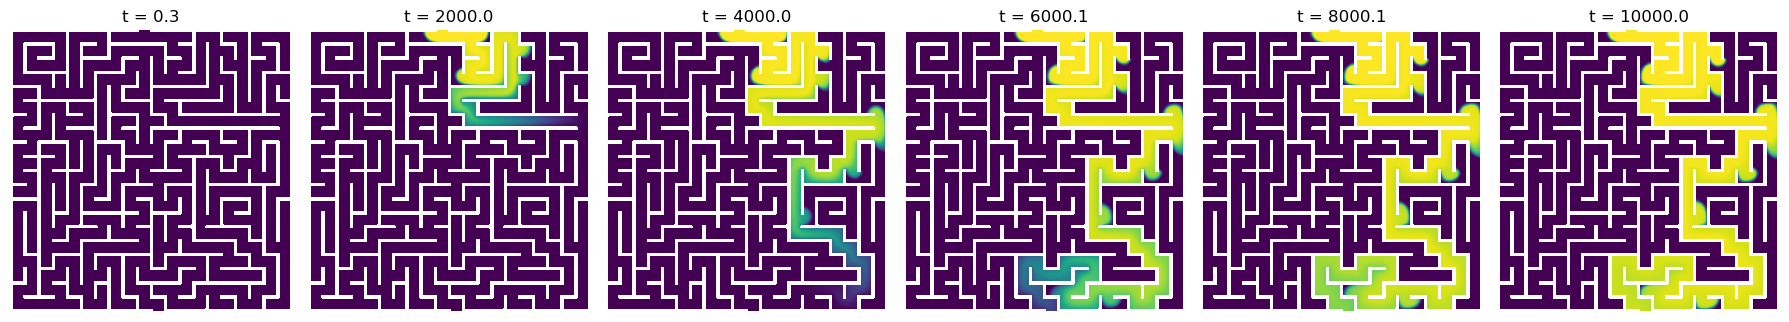

In [24]:
import time
import numpy as np
import matplotlib.pyplot as plt


# ------------------------------------------------------------
# 1. Données
# ------------------------------------------------------------
def charger():
    U = np.load('U.npy')                       # (Ny, Nx+1) : U[i,j] = face gauche de (i,j)
    V = np.load('V.npy')                       # (Ny+1, Nx) : V[i,j] = face haute  de (i,j)
    dom = np.loadtxt('out_domain.txt', dtype=int)
    return U, V, dom


# ------------------------------------------------------------
# 2. Pas de temps (condition CFL de l'upwind explicite)
# ------------------------------------------------------------
def pas_de_temps(U, V, dx, dy, cfl):
    # somme, pour chaque cellule, des vitesses SORTANTES (divisées par la taille de maille)
    sortant = (np.maximum(U[:, 1:], 0) + np.maximum(-U[:, :-1], 0)) / dx \
            + (np.maximum(V[1:, :], 0) + np.maximum(-V[:-1, :], 0)) / dy
    return cfl / sortant.max()


# ------------------------------------------------------------
# 3. Second membre : dc/dt = -(divergence des flux), flux upwind
# ------------------------------------------------------------
def flux_upwind(c, U, V, c_in, inlet):
    i_in, j_in = inlet
    cp = np.pad(c, 1)                          # cellules fantômes (0) autour du tableau
    cp[i_in, j_in + 1] = c_in                  # fantôme situé juste au-dessus de l'entrée
                                               # (indices décalés de +1 à cause du pad)
    # faces verticales : cellule gauche / droite
    cL, cR = cp[1:-1, :-1], cp[1:-1, 1:]
    F = U * np.where(U > 0, cL, cR)
    # faces horizontales : cellule haute / basse
    cT, cB = cp[:-1, 1:-1], cp[1:, 1:-1]
    G = V * np.where(V > 0, cT, cB)
    return F, G


def rhs(c, U, V, dx, dy, c_in, inlet, fluid):
    F, G = flux_upwind(c, U, V, c_in, inlet)
    dcdt = -(F[:, 1:] - F[:, :-1]) / dx - (G[1:, :] - G[:-1, :]) / dy
    return np.where(fluid, dcdt, 0.0), F, G


# ------------------------------------------------------------
# 4. Boucle en temps (Euler explicite) avec suivi de progression
# ------------------------------------------------------------
def simuler(U, V, dom, dx=1.0, dy=1.0, cfl=0.5, t_end=10000.0,
            c_in_val=1.0, t_inj=None, n_snap=6):
    fluid = dom > 0
    rows_bc = np.where((dom == 2).any(axis=1))[0]
    i_in, i_out = rows_bc.min(), rows_bc.max()
    j_in = np.where(dom[i_in, :] == 2)[0]
    j_out = np.where(dom[i_out, :] == 2)[0]
    inlet = (i_in, j_in)

    dt0 = pas_de_temps(U, V, dx, dy, cfl)
    n_total = int(np.ceil(t_end / dt0))        # nombre de pas prévu
    freq = max(1, n_total // 20)               # affichage ~20 fois pendant le calcul

    c = np.zeros(dom.shape)
    t, m_in, m_out = 0.0, 0.0, 0.0
    snap_times = np.linspace(0, t_end, n_snap)
    snaps, k = [], 0

    n = 0                                      # compteur de pas
    t_start = time.perf_counter()              # début du chronomètre
    print(f"Début : dt = {dt0:.4f}, {n_total} pas prévus")

    while t < t_end:
        dt = min(dt0, t_end - t)
        c_in = c_in_val if (t_inj is None or t < t_inj) else 0.0

        d, F, G = rhs(c, U, V, dx, dy, c_in, inlet, fluid)

        # bilan de masse : ce qui entre / sort par les faces d'entrée et de sortie
        m_in += dt * (G[i_in, j_in]).sum() * dx
        m_out += dt * (G[i_out + 1, j_out]).sum() * dx

        c = c + dt * d                         # Euler explicite
        t += dt
        n += 1

        # suivi de progression
        if n % freq == 0:
            ecoule = time.perf_counter() - t_start
            frac = t / t_end
            restant = ecoule / frac - ecoule   # extrapolation linéaire
            print(f"  {100*frac:5.1f} %  |  pas {n}/{n_total}  |  "
                  f"écoulé {ecoule:6.1f} s  |  restant ~{restant:6.1f} s")

        if k < n_snap and t >= snap_times[k] - 1e-12:
            snaps.append((t, c.copy()))
            k += 1

    duree = time.perf_counter() - t_start
    masse = c[fluid].sum() * dx * dy
    print(f"Temps de calcul : {duree:.2f} s ({duree/n*1e3:.3f} ms par pas)")
    print(f"dt = {dt0:.4f}   nb de pas = {n}")
    print(f"Masse dans le domaine : {masse:.6f}")
    print(f"Masse entrée - sortie : {(m_in - m_out) * dy:.6f}")
    print(f"Erreur de conservation : {abs(masse - (m_in - m_out) * dy):.2e}")
    print(f"c min = {c[fluid].min():.3e}   c max = {c[fluid].max():.6f}")
    return c, snaps


# ------------------------------------------------------------
# 5. Test : un champ constant doit le rester
# ------------------------------------------------------------
def test_champ_constant(U, V, dom, dx=1.0, dy=1.0):
    fluid = dom > 0
    rows_bc = np.where((dom == 2).any(axis=1))[0]
    i_in = rows_bc.min()
    j_in = np.where(dom[i_in, :] == 2)[0]
    c = np.where(fluid, 1.0, 0.0)
    d, _, _ = rhs(c, U, V, dx, dy, 1.0, (i_in, j_in), fluid)
    print("Test c = 1 : max |dc/dt| =", np.abs(d).max())


# ------------------------------------------------------------
# 6. Visualisation
# ------------------------------------------------------------
def tracer(snaps, dom):
    fluid = dom > 0
    n = len(snaps)
    fig, axs = plt.subplots(1, n, figsize=(3 * n, 4))
    for ax, (t, c) in zip(np.atleast_1d(axs), snaps):
        ax.imshow(np.where(fluid, c, np.nan), vmin=0, vmax=1)
        ax.set_title(f"t = {t:.1f}")
        ax.axis('off')
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    U, V, dom = charger()
    test_champ_constant(U, V, dom)
    c, snaps = simuler(U, V, dom, cfl=0.5, t_end=10000.0)
    tracer(snaps, dom)

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from fv_solver import cl_labyrinthe, simuler


def images(limiteur='vanleer', temps='rk3', cfl=0.4, n_images=6, facteur_t=1.5,
           t_inj=None, par_ligne=3):
    U = np.load('U.npy'); V = np.load('V.npy')
    dom = np.loadtxt('out_domain.txt', dtype=int)
    cl = cl_labyrinthe(dom)
    fluid = cl['fluid']

    # Durée = facteur_t x temps de séjour moyen (volume de fluide / débit)
    t_end = facteur_t * fluid.sum() / V[cl['i_out'] + 1, cl['j_out']].sum()

    r = simuler(np.zeros(dom.shape), U, V, 1.0, 1.0, cl, limiteur, temps, cfl,
                t_end, t_inj=t_inj, n_snap=n_images)

    n_lig = int(np.ceil(n_images / par_ligne))
    h, w = dom.shape
    fig, axs = plt.subplots(n_lig, par_ligne,
                            figsize=(5 * par_ligne, 5 * h / w * n_lig + 0.5 * n_lig),
                            squeeze=False)
    for ax in axs.ravel():
        ax.axis('off')
    for ax, (t, c) in zip(axs.ravel(), r['snaps']):
        ax.imshow(np.where(fluid, np.nan, 1.0), cmap='gray_r', vmin=0, vmax=2)   # murs
        im = ax.imshow(np.where(fluid, c, np.nan), vmin=0, vmax=1)
        ax.set_title(f't = {t:.0f}')
    fig.colorbar(im, ax=axs, shrink=0.6, label='concentration c')
    plt.show()


if __name__ == "__main__":
    images()

ModuleNotFoundError: No module named 'fv_solver'